## **Q2: How do learner counts, disability profiles, and geographic distribution differ when analyzed using diagnosed disability records compared with manifestation records?**

**Datasets used in this notebook**

| File | Role |
|---|---|
| `sned_database_tidy_long.parquet` | SNED learner counts by school, disability category, diagnosis type, grade, and sex. Queried through DuckDB throughout so the raw table is never loaded into pandas. |
| `SY 2025-2026 SCHOOL LEVEL DATA ON ENROLLMENT BY SCHOOL.xlsx` | Total enrollment per school. |
| `public_school_coordinates.parquet` | School-level PSGC geography (region/province/municipality) for public schools. |
| `private_school_coordinates.parquet` | Same, for private schools. |
| `consolidated_geodata_matched.gpkg` | Municipality/province/country boundary polygons. |

### **A. Preliminaries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import geopandas as gpd
import duckdb
from scipy import stats
from IPython.display import display
pd.set_option('display.max_columns', None)

REGION_SHORT = {
    'Region I (Ilocos Region)':       'Ilocos Region',
    'Region II (Cagayan Valley)':     'Cagayan Valley',
    'Cordillera Administrative Region (CAR)': 'CAR',
    'Region III (Central Luzon)':     'Central Luzon',
    'National Capital Region (NCR)':  'NCR',
    'Region IV-A (CALABARZON)':       'CALABARZON',
    'MIMAROPA Region':                'MIMAROPA',
    'Region V (Bicol Region)':        'Bicol Region',
    'Region VI (Western Visayas)':    'Western Visayas',
    'Negros Island Region (NIR)':     'NIR',
    'Region VII (Central Visayas)':   'Central Visayas',
    'Region VIII (Eastern Visayas)':  'Eastern Visayas',
    'Region IX (Zamboanga Peninsula)':'Zamboanga Peninsula',
    'Region X (Northern Mindanao)':   'Northern Mindanao',
    'Region XI (Davao Region)':       'Davao Region',
    'Region XII (SOCCSKSARGEN)':      'SOCCSKSARGEN',
    'Region XIII (Caraga)':           'Caraga',
    'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)': 'BARMM',
}
REGION_ORDER = list(REGION_SHORT.values())

MANIFESTATION_ABBREV = {
    'Difficulty in Remembering, Concentrating, Paying Attention and Understanding': 'DRCPAU',
    'Difficulty in Applying Knowledge':                    'DAK',
    'Difficulty in Seeing':                                'DSeeing',
    'Difficulty in Communicating':                         'DComm',
    'Difficulty in Displaying Inter-Personal Behavior':    'DDIB',
    'Difficulty in Mobility (Walking, Climbing and Grasping)': 'DMobility',
    'Difficulty in Applying Adaptive Skills':              'DAAS',
    'Difficulty in Hearing':                                'DHearing',
}
DIAGNOSED_ABBREV = {
    'Autism Spectrum Disorder':                'ASD',
    'Intellectual Disability':                 'ID',
    'Learning Disability':                     'LD',
    'Speech/Language Disorder':                 'S/LD',
    'Visual Impairment':                        'VI',
    'Hearing Impairment':                       'HI',
    'Orthopedic/Physical Handicap':             'O/PH',
    'Emotional-Behavioral Disorder':            'EBD',
    'Multiple Disabilities':                    'MD',
    'Special Health Problem/Chronic Disease':   'SHP/CD',
    'Cerebral Palsy':                           'CP',
}
CATEGORY_ABBREV = {**MANIFESTATION_ABBREV, **DIAGNOSED_ABBREV}

# Optional: only keep this if you're deliberately using Inter in these charts.
from pyfonts import set_default_font, load_google_font
regular = load_google_font("Inter")
bold    = load_google_font("Inter", weight="bold")
set_default_font(regular)

_ROOT = Path.cwd().parent
DATA  = _ROOT / "data"

DIAGNOSED  = 'With Diagnosis from Licensed Medical Specialist'
MANIFEST   = 'With Manifestations'

SNED_PARQUET   = DATA / "sned_database_tidy_long.parquet"
ENROLL_XLSX    = DATA / "external" / "SY 2025-2026 SCHOOL LEVEL DATA ON ENROLLMENT BY SCHOOL.xlsx"
PUBLIC_COORDS  = DATA / "external" / "public_school_coordinates.parquet"
PRIVATE_COORDS = DATA / "external" / "private_school_coordinates.parquet"
GEO_GPKG       = DATA / "external" / "consolidated_geodata_matched.gpkg"

con = duckdb.connect()
con.execute(f"SELECT COUNT(*) AS n_rows FROM read_parquet('{SNED_PARQUET.as_posix()}')").df()

FIG_DIR = Path.cwd() / "figures"
# FIG_DIR.mkdir(exist_ok=True)

SNED_SQL = SNED_PARQUET.as_posix()

MIN_N_MUNI = 30    # min identified learners (D+M) for a municipality to be ranked/labelled
MIN_N_PROV = 100   # same, for provinces/HUCs
MIN_N_CELL = 30    # min identified learners for a heatmap cell to be shown

COLOR_DX = '#2166ac'   # diagnosis-reliant (above national diagnosed share)
COLOR_MF = '#b2182b'   # manifestation-reliant (below national diagnosed share)

CAT_DX = plt.cm.Set2.colors[0]   # '#66c2a5' — pastel green/teal, "Diagnosed"
CAT_MF = plt.cm.Set2.colors[1]   # '#fc8d62' — pastel orange, "Manifestation"

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set2.colors)

ISLAND_GROUP = {
    **{r: 'Luzon'    for r in ['Ilocos Region', 'Cagayan Valley', 'CAR', 'Central Luzon', 'NCR',
                               'CALABARZON', 'MIMAROPA', 'Bicol Region']},
    **{r: 'Visayas'  for r in ['Western Visayas', 'NIR', 'Central Visayas', 'Eastern Visayas']},
    **{r: 'Mindanao' for r in ['Zamboanga Peninsula', 'Northern Mindanao', 'Davao Region',
                               'SOCCSKSARGEN', 'Caraga', 'BARMM']},
}

# Analyst-constructed crosswalk from both taxonomies into shared functional domains.
# APPROXIMATE by design; ASD spans two domains, so its assignment is a sensitivity parameter.
DOMAIN_ORDER = ['Vision', 'Hearing', 'Physical/motor', 'Communication',
                'Cognitive/learning', 'Socio-behavioral']

def build_domain_map(asd_domain='Socio-behavioral'):
    assert asd_domain in DOMAIN_ORDER
    return {
        'Visual Impairment': 'Vision',            'Difficulty in Seeing': 'Vision',
        'Hearing Impairment': 'Hearing',          'Difficulty in Hearing': 'Hearing',
        'Orthopedic/Physical Handicap': 'Physical/motor',
        'Cerebral Palsy': 'Physical/motor',
        'Difficulty in Mobility (Walking, Climbing and Grasping)': 'Physical/motor',
        'Speech/Language Disorder': 'Communication',
        'Difficulty in Communicating': 'Communication',
        'Learning Disability': 'Cognitive/learning',
        'Intellectual Disability': 'Cognitive/learning',
        'Difficulty in Applying Knowledge': 'Cognitive/learning',
        'Difficulty in Remembering, Concentrating, Paying Attention and Understanding': 'Cognitive/learning',
        'Difficulty in Applying Adaptive Skills': 'Cognitive/learning',
        'Emotional-Behavioral Disorder': 'Socio-behavioral',
        'Difficulty in Displaying Inter-Personal Behavior': 'Socio-behavioral',
        'Autism Spectrum Disorder': asd_domain,
        # no functional counterpart on the manifestation side
        'Multiple Disabilities': 'Unmappable',
        'Special Health Problem/Chronic Disease': 'Unmappable',
    }

ASD_DOMAIN = 'Socio-behavioral'   # sensitivity run: 'Communication'
DOMAIN_MAP = build_domain_map(ASD_DOMAIN)

In [2]:
# Extract non-zero cells + per-school totals
sned_nz = con.execute(f"""
    SELECT CAST(beis_school_id AS BIGINT) AS school_id,
           Sector         AS sector,
           School_Level   AS school_level,
           Program        AS program,
           Diagnosis_Type AS diag_type,
           Category       AS category,
           Grade_Level    AS grade_level,
           Sex            AS sex,
           SUM(Learner_Count)::BIGINT AS n
    FROM read_parquet('{SNED_SQL}')
    WHERE Learner_Count > 0
    GROUP BY ALL
""").df()

sned_school = con.execute(f"""
    SELECT CAST(beis_school_id AS BIGINT) AS school_id,
           ANY_VALUE(Sector) AS sector,
           SUM(CASE WHEN Diagnosis_Type = ? THEN COALESCE(Learner_Count, 0) ELSE 0 END)::BIGINT AS dx,
           SUM(CASE WHEN Diagnosis_Type = ? THEN COALESCE(Learner_Count, 0) ELSE 0 END)::BIGINT AS mf
    FROM read_parquet('{SNED_SQL}')
    GROUP BY 1
""", [DIAGNOSED, MANIFEST]).df()
sned_school['identified'] = sned_school['dx'] + sned_school['mf']

assert set(sned_nz['diag_type'].unique()) <= {DIAGNOSED, MANIFEST}, sned_nz['diag_type'].unique()
assert sned_nz['n'].sum() == sned_school['identified'].sum()
print(f"{len(sned_nz):,} non-zero cells | {len(sned_school):,} schools in SNED DB")
print(sned_school['sector'].value_counts(dropna=False))

category_totals = (sned_nz.groupby(['diag_type', 'category'], as_index=False)['n'].sum()
                          .rename(columns={'category': 'Category'}))
unmapped = set(category_totals['Category'].unique()) - set(CATEGORY_ABBREV.keys())
if unmapped:
    print("WARNING — categories with no abbreviation mapping:", unmapped)
unmapped_dom = set(category_totals['Category'].unique()) - set(DOMAIN_MAP.keys())
if unmapped_dom:
    print("WARNING — categories with no domain mapping:", unmapped_dom)

# School-level geography (PSGC-code-based, not text-name matching)
GEO_COLS = ['school_id', 'psgc_region', 'psgc_region_name', 'psgc_province', 'psgc_province_name',
            'psgc_municity', 'psgc_municity_name', 'urban_rural', 'income_class']

school_geo = pd.concat(
    [pd.read_parquet(PUBLIC_COORDS,  columns=GEO_COLS).assign(coord_file='public'),
     pd.read_parquet(PRIVATE_COORDS, columns=GEO_COLS).assign(coord_file='private')],
    ignore_index=True)
for c in ['school_id', 'psgc_region', 'psgc_province', 'psgc_municity']:
    school_geo[c] = pd.to_numeric(school_geo[c], errors='coerce').astype('Int64')

n_dup = school_geo['school_id'].duplicated().sum()
print(f"{n_dup:,} school_ids appear in both coordinate files (keeping the public record)")
school_geo = school_geo.drop_duplicates('school_id', keep='first')
school_geo['region_short'] = school_geo['psgc_region_name'].map(REGION_SHORT)
school_geo['island_group'] = school_geo['region_short'].map(ISLAND_GROUP)
school_geo['urban_rural'] = school_geo['urban_rural'].map({'U': 'Urban', 'R': 'Rural'})

sned_school_geo = sned_school.merge(school_geo, on='school_id', how='left', validate='1:1')

unmatched = sned_school_geo['psgc_municity'].isna()
audit = (sned_school_geo.assign(unmatched=unmatched)
         .groupby('sector')
         .agg(schools=('school_id', 'size'),
              schools_unmatched=('unmatched', 'sum'),
              identified=('identified', 'sum'),
              identified_unmatched=('identified', lambda s: s[unmatched.loc[s.index]].sum())))
audit['pct_identified_lost'] = (audit['identified_unmatched'] / audit['identified'] * 100).round(2)
display(audit)

sned_nz = sned_nz.merge(
    school_geo[['school_id', 'psgc_region_name', 'region_short', 'island_group', 'psgc_province',
                'psgc_province_name', 'psgc_municity', 'psgc_municity_name', 'urban_rural']],
    on='school_id', how='left')
sned_nz['domain'] = sned_nz['category'].map(DOMAIN_MAP)
sned_nz['is_dx'] = sned_nz['diag_type'].eq(DIAGNOSED)

# Enrollment universe
enroll_raw = pd.read_excel(ENROLL_XLSX, sheet_name='DATABASE', header=5)
enroll_raw = enroll_raw.rename(columns={'beis_school_id': 'school_id'})
enroll_raw['school_id'] = pd.to_numeric(enroll_raw['school_id'], errors='coerce').astype('Int64')

ENR_PATTERN = r'^(k|g\d+|ngElem|ngSecon)(male|female)(?:_.*)?$'
enr_cols = [c for c in enroll_raw.columns if pd.Series([c]).str.match(ENR_PATTERN).iat[0]]

enroll_long = enroll_raw[['school_id'] + enr_cols].melt(id_vars='school_id', var_name='col', value_name='enrolled')
parts = enroll_long['col'].str.extract(ENR_PATTERN)
GRADE_KEY = {'k': 'Kindergarten', 'ngElem': 'Non-Graded', 'ngSecon': 'Non-Graded (JHS)',
             **{f'g{i}': f'Grade {i}' for i in range(1, 13)}}
enroll_long['grade_key'] = parts[0].map(GRADE_KEY)
enroll_long['sex'] = parts[1].map({'male': 'Male', 'female': 'Female'})
enroll_long['enrolled'] = pd.to_numeric(enroll_long['enrolled'], errors='coerce').fillna(0)
enroll_long = enroll_long.groupby(['school_id', 'grade_key', 'sex'], as_index=False)['enrolled'].sum()
school_enrolment = enroll_long.groupby('school_id')['enrolled'].sum()

NONGRADED = {'Level I': 'Non-Graded', 'Level II': 'Non-Graded', 'Level III': 'Non-Graded', 'Transition': 'Non-Graded'}
cell_chk = (sned_nz.assign(grade_key=sned_nz['grade_level'].replace(NONGRADED))
            .pivot_table(index=['school_id', 'grade_key', 'sex'], columns='diag_type',
                         values='n', aggfunc='sum', fill_value=0)
            .reindex(columns=[DIAGNOSED, MANIFEST], fill_value=0)
            .rename(columns={DIAGNOSED: 'dx', MANIFEST: 'mf'})
            .reset_index()
            .merge(enroll_long, on=['school_id', 'grade_key', 'sex'], how='left'))
cell_chk['mf_gt_enrol'] = cell_chk['mf'] > cell_chk['enrolled']
cell_chk['dxmf_gt_enrol'] = (cell_chk['dx'] + cell_chk['mf']) > cell_chk['enrolled']

has_enr = cell_chk['enrolled'].notna()
print(f"Grade-sex cells with identified learners: {len(cell_chk):,} "
      f"({(~has_enr).sum():,} have no matching enrolment cell)")
for flag, label in [('mf_gt_enrol', 'manifestations > enrolment'),
                    ('dxmf_gt_enrol', 'diagnosed + manifestations > enrolment')]:
    sub = cell_chk[has_enr & cell_chk[flag]]
    print(f"  {label}: {len(sub):,} cells ({len(sub)/has_enr.sum():.2%}), "
          f"holding {sub['mf'].sum():,} manifestation records "
          f"({sub['mf'].sum()/cell_chk['mf'].sum():.2%} of all)")


301,563 non-zero cells | 59,997 schools in SNED DB
sector
Public     48129
Private    11868
Name: count, dtype: int64
0 school_ids appear in both coordinate files (keeping the public record)


,schools,schools_unmatched,identified,identified_unmatched,pct_identified_lost
sector,,,,,
Private,11868,224,31037,430,1.39
Public,48129,326,492902,2471,0.50


Grade-sex cells with identified learners: 175,534 (0 have no matching enrolment cell)
  manifestations > enrolment: 45 cells (0.03%), holding 349 manifestation records (0.11% of all)
  diagnosed + manifestations > enrolment: 188 cells (0.11%), holding 738 manifestation records (0.23% of all)


### **B. Diagnostic status and disabiliy profile, by region**

regime
Both                   19978
Diagnosed only          7335
Manifestation only     11035
Neither (all zeros)    21611
Not in SNED DB           199
Name: count, dtype: int64

Share of each record type held by schools in each regime:
                       dx    mf
regime                         
Both                 91.2  82.8
Diagnosed only        8.8   0.0
Manifestation only    0.0  17.2
Neither (all zeros)   0.0   0.0
Not in SNED DB        0.0   0.0


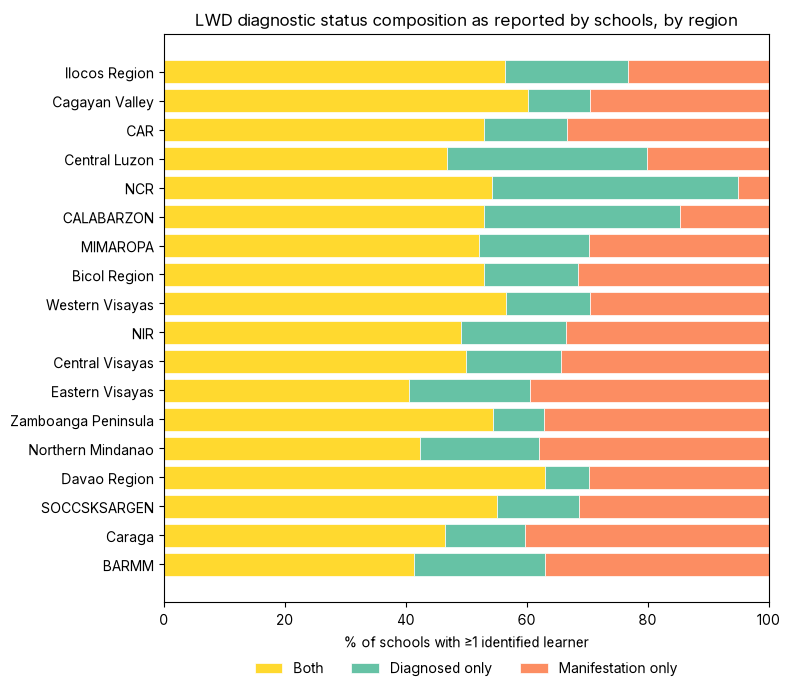

In [3]:
# ==========================================================================
# Diagnostic type-regime mix (Diagnosed / Manifestation / Both) by
# region: how consistently schools record both diagnostic tracks.
# ==========================================================================
universe = school_enrolment[school_enrolment > 0].rename('enrolled').reset_index()
regime_df = universe.merge(sned_school_geo, on='school_id', how='left')
regime_df['regime'] = np.select(
    [regime_df['dx'].isna(),
     (regime_df['dx'] > 0) & (regime_df['mf'] > 0),
     regime_df['dx'] > 0,
     regime_df['mf'] > 0],
    ['Not in SNED DB', 'Both', 'Diagnosed only', 'Manifestation only'],
    default='Neither (all zeros)')

REGIME_ORDER = ['Both', 'Diagnosed only', 'Manifestation only', 'Neither (all zeros)', 'Not in SNED DB']
REGIME_COLORS = ['#FFD92F', CAT_DX, CAT_MF, '#d9d9d9', '#f4f4f4']

print(regime_df['regime'].value_counts().reindex(REGIME_ORDER, fill_value=0))
lr = regime_df.groupby('regime')[['dx', 'mf']].sum()
print("\nShare of each record type held by schools in each regime:")
print((lr / lr.sum() * 100).round(1).reindex(REGIME_ORDER).dropna(how='all'))

ident = regime_df[regime_df['identified'] > 0]
reg_mix = (pd.crosstab(ident['region_short'], ident['regime'], normalize='index')
             .reindex(index=REGION_ORDER, columns=REGIME_ORDER[:3]).fillna(0) * 100)

fig, ax = plt.subplots(figsize=(8, 7))
left = np.zeros(len(reg_mix))
for reg, col in zip(REGIME_ORDER[:3], REGIME_COLORS[:3]):
    ax.barh(reg_mix.index, reg_mix[reg], left=left, color=col, label=reg, edgecolor='white', lw=0.5)
    left += reg_mix[reg].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 100); ax.set_xlabel('% of schools with ≥1 identified learner')
ax.set_title('LWD diagnostic status composition as reported by schools, by region')
ax.legend(ncols=3, loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.tight_layout()
# fig.savefig(FIG_DIR / "rq2_reporting_regime_by_region.png", dpi=300, bbox_inches='tight')
plt.show()

Records in unmappable categories (MD, SHP/CD), excluded from domain analyses: 11,822 (5.8% of diagnosed)


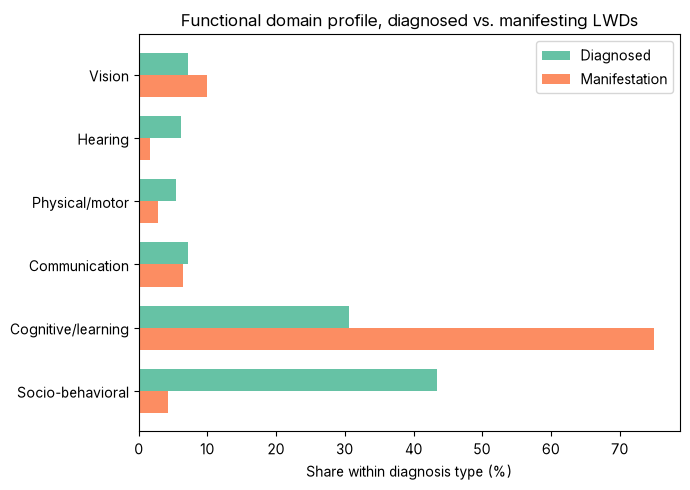

In [4]:
# ==========================================================================
# Rstricts to the 6 functional domains; MD and Special Health Problem/Chronic Disease 
# (diagnosed-only, no manifestation counterpart) are dropped here.
# ==========================================================================
dom_nz = sned_nz[sned_nz['domain'].isin(DOMAIN_ORDER)]
print(f"Records in unmappable categories (MD, SHP/CD), excluded from domain analyses: "
      f"{sned_nz.loc[sned_nz['domain'] == 'Unmappable', 'n'].sum():,} "
      f"({sned_nz.loc[sned_nz['domain'] == 'Unmappable', 'n'].sum() / sned_nz.loc[sned_nz['is_dx'], 'n'].sum():.1%} of diagnosed)")


# ==========================================================================
# Functional-domain profile: share of each diagnosis type's
# records falling into each of the 6 functional domains.
# ==========================================================================
domain_totals = dom_nz.groupby(['diag_type', 'domain'], as_index=False)['n'].sum()
domain_totals['share_within_type'] = domain_totals.groupby('diag_type')['n'].transform(lambda s: s / s.sum())
domain_share_pivot = domain_totals.pivot(index='domain', columns='diag_type', values='share_within_type').fillna(0)
domain_share_pivot = domain_share_pivot[[DIAGNOSED, MANIFEST]].reindex(DOMAIN_ORDER)

fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(domain_share_pivot))
height = 0.35
ax.barh(y - height/2, domain_share_pivot[DIAGNOSED] * 100, height=height, label='Diagnosed', color=CAT_DX)
ax.barh(y + height/2, domain_share_pivot[MANIFEST] * 100, height=height, label='Manifestation', color=CAT_MF)
ax.set_yticks(y); ax.set_yticklabels(domain_share_pivot.index)
ax.invert_yaxis()
ax.set_xlabel('Share within diagnosis type (%)')
ax.set_title('Functional domain profile, diagnosed vs. manifesting LWDs')
ax.legend(frameon=True)
plt.tight_layout()
# fig.savefig(FIG_DIR / "rq2_functional_domain_profile.png", dpi=300, bbox_inches='tight')
plt.show()


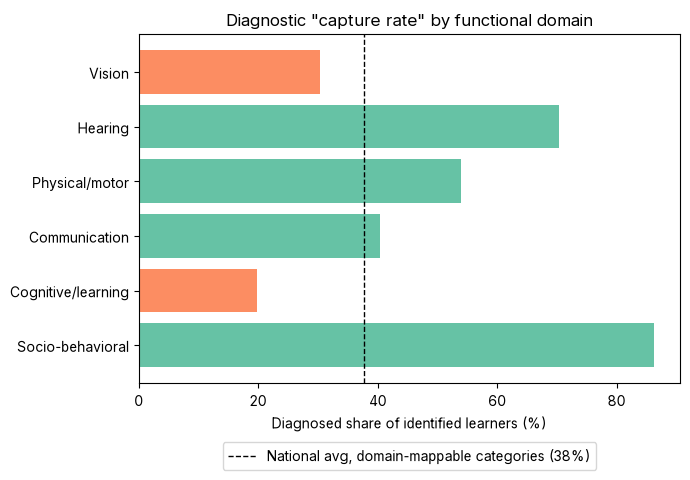

In [5]:
# ==========================================================================
# Diagnostic "capture rate": % of each domain's identified
# learners who have a formal diagnosis rather than a manifestation-only record.
# ==========================================================================
def dx_share_table(df, index):
    t = (df.assign(dx=np.where(df['is_dx'], df['n'], 0))
           .groupby(index, dropna=True).agg(dx=('dx', 'sum'), identified=('n', 'sum')))
    t['dx_share'] = t['dx'] / t['identified']
    return t

nat_dom = dx_share_table(dom_nz, ['domain'])['dx_share'].reindex(DOMAIN_ORDER)

# For domain-mappable categories only
overall_capture_domains = dom_nz.loc[dom_nz['is_dx'], 'n'].sum() / dom_nz['n'].sum()

fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(nat_dom))
colors = [CAT_DX if v >= overall_capture_domains else CAT_MF for v in nat_dom]
ax.barh(y, nat_dom * 100, color=colors)
ax.axvline(overall_capture_domains * 100, color='black', linestyle='--', linewidth=1,
           label=f'National avg, domain-mappable categories ({overall_capture_domains:.0%})')
ax.set_yticks(y); ax.set_yticklabels(nat_dom.index)
ax.invert_yaxis()
ax.set_xlabel('Diagnosed share of identified learners (%)')
ax.set_title('Diagnostic "capture rate" by functional domain')
ax.legend(frameon=True, loc="lower center", bbox_to_anchor=(0.5, -0.27))
plt.tight_layout()
# fig.savefig(FIG_DIR / "rq2_domain_capture_rate.png", dpi=300, bbox_inches='tight')
plt.show()


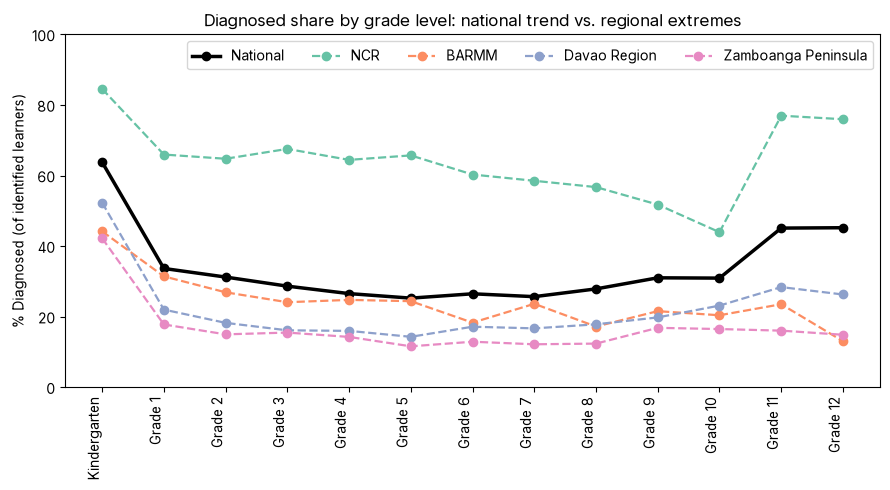

In [6]:
# ==========================================================================
# Diagnosed share by grade level: national trend vs. 4 regional
# extremes (NCR, BARMM, Davao Region, Zamboanga Peninsula).
# ==========================================================================
GRADE_ORDER = ['Kindergarten'] + [f'Grade {i}' for i in range(1, 13)]  # matches Cell 13's convention
grade_data = sned_nz[sned_nz['grade_level'].isin(GRADE_ORDER)]

national_grade = grade_data.groupby(['grade_level', 'diag_type'], as_index=False)['n'].sum()
national_grade['region_short'] = 'National'

HIGHLIGHT_REGIONS = ['NCR', 'BARMM', 'Davao Region', 'Zamboanga Peninsula']
regional_grade = (
    grade_data[grade_data['region_short'].isin(HIGHLIGHT_REGIONS)]
    .groupby(['region_short', 'grade_level', 'diag_type'], as_index=False)['n'].sum()
)
combined_grade = pd.concat(
    [national_grade[['region_short', 'grade_level', 'diag_type', 'n']], regional_grade], ignore_index=True
)
grade_pivot = combined_grade.pivot_table(index=['region_short', 'grade_level'], columns='diag_type', values='n', fill_value=0)
grade_pivot['identified'] = grade_pivot[DIAGNOSED] + grade_pivot[MANIFEST]
grade_pivot['dx_share'] = grade_pivot[DIAGNOSED] / grade_pivot['identified']
grade_pivot = grade_pivot.reset_index()

REGION_LINE_STYLES = {
    'National':            {'color': 'black',              'linestyle': '-',  'linewidth': 2.5},
    'NCR':                 {'color': plt.cm.Set2.colors[0], 'linestyle': '--', 'linewidth': 1.6},
    'BARMM':               {'color': plt.cm.Set2.colors[1], 'linestyle': '--', 'linewidth': 1.6},
    'Davao Region':        {'color': plt.cm.Set2.colors[2], 'linestyle': '--', 'linewidth': 1.6},
    'Zamboanga Peninsula': {'color': plt.cm.Set2.colors[3], 'linestyle': '--', 'linewidth': 1.6},
}

fig, ax = plt.subplots(figsize=(9, 5))
for grp, style in REGION_LINE_STYLES.items():
    sub = grade_pivot[grade_pivot['region_short'] == grp].set_index('grade_level').reindex(GRADE_ORDER)
    ax.plot(GRADE_ORDER, sub['dx_share'] * 100, marker='o', label=grp, **style)
plt.setp(ax.get_xticklabels(), rotation=90, ha='right')
ax.set_ylabel('% Diagnosed (of identified learners)')
ax.set_ylim(0, 100)
ax.set_title('Diagnosed share by grade level: national trend vs. regional extremes')
ax.legend(frameon=True, loc="upper right", ncol=5)
plt.tight_layout()
# fig.savefig(FIG_DIR / "rq2_grade_trajectory.png", dpi=300, bbox_inches='tight')
plt.show()

### **C. Provincial and national outlook**

In [20]:
def summarise_share(df, keys):
    out = df.groupby(keys, dropna=True).agg(dx=('dx', 'sum'), mf=('mf', 'sum')).reset_index()
    out['identified'] = out['dx'] + out['mf']
    out = out[out['identified'] > 0].copy()
    out['dx_share'] = out['dx'] / out['identified']
    return out

def funnel_z(k, n, p0, winsor=0.10):
    """Spiegelhalter (2005) funnel z-scores with multiplicative overdispersion."""
    z = (k / n - p0) / np.sqrt(p0 * (1 - p0) / n)
    lo, hi = np.nanquantile(z, [winsor, 1 - winsor])
    phi = max(1.0, np.mean(np.clip(z, lo, hi) ** 2))
    return z / np.sqrt(phi), phi

geo_school = sned_school_geo.dropna(subset=['psgc_municity'])
P0 = geo_school['dx'].sum() / geo_school['identified'].sum()
print(f"National diagnosed share (geo-matched schools): {P0:.2%}")

prov = summarise_share(geo_school, ['psgc_province']).merge(
    geo_school.groupby('psgc_province')[['psgc_province_name', 'region_short']].first().reset_index(),
    on='psgc_province')

prov['low_n'] = prov['identified'] < MIN_N_PROV
prov['gap_pp'] = (prov['dx_share'] - P0) * 100
prov['z_adj'], PHI_PROV = funnel_z(prov['dx'], prov['identified'], P0)

National diagnosed share (geo-matched schools): 39.08%


In [21]:
# ==========================================================================
# Builds municipality/province/country boundary layers from the
# geopackage, with the Negros Island Region (NIR) PSGC-code fix applied.
# ==========================================================================
geodata = gpd.read_file(GEO_GPKG)
usable = geodata[geodata['geometry'].notna() & geodata['adm3_psgc'].notna()].copy()

usable['adm3_psgc'] = (pd.to_numeric(usable['adm3_psgc'], errors='coerce')
                         .astype('Int64').astype('string').str.zfill(10))

NIR_PROVINCES = {"Negros Occidental", "Negros Oriental", "Siquijor"}
is_nir = usable["adm2_en"].isin(NIR_PROVINCES)
usable.loc[is_nir, "adm1_en"] = "Negros Island Region (NIR)"
usable.loc[is_nir, "adm3_psgc"] = "18" + usable.loc[is_nir, "adm3_psgc"].str[2:]
print(f"{is_nir.sum():,} rows reassigned to NIR. Check Bacolod is among them if the file lists it as its own adm2:")
print(usable.loc[usable['adm3_psgc'].str.startswith('18'), 'adm2_en'].unique())

muni_gdf = usable[['adm3_psgc', 'geometry']].dissolve(by='adm3_psgc').reset_index()
muni_gdf['psgc_municity'] = pd.to_numeric(muni_gdf['adm3_psgc']).astype('Int64')
tol = 0.001 if muni_gdf.crs is not None and muni_gdf.crs.is_geographic else 100
muni_gdf['geometry'] = muni_gdf.geometry.simplify(tol, preserve_topology=True)

muni_keys = (school_geo.dropna(subset=['psgc_municity'])
             .groupby('psgc_municity')[['psgc_province', 'psgc_province_name', 'psgc_region', 'region_short']]
             .agg(lambda s: s.mode().iat[0] if s.notna().any() else pd.NA).reset_index())
muni_gdf = muni_gdf.merge(muni_keys, on='psgc_municity', how='left')
print(f"Municipal polygons without a school-side key (drawn as background only): "
      f"{muni_gdf['psgc_province'].isna().sum():,} of {len(muni_gdf):,}")

prov_gdf = muni_gdf.dropna(subset=['psgc_province']).dissolve(by='psgc_province').reset_index()
base_gdf = muni_gdf.dissolve().geometry


1,353 rows reassigned to NIR. Check Bacolod is among them if the file lists it as its own adm2:
<ArrowStringArray>
['Negros Occidental', 'Negros Oriental', 'Siquijor']
Length: 3, dtype: str
Municipal polygons without a school-side key (drawn as background only): 1 of 1,582


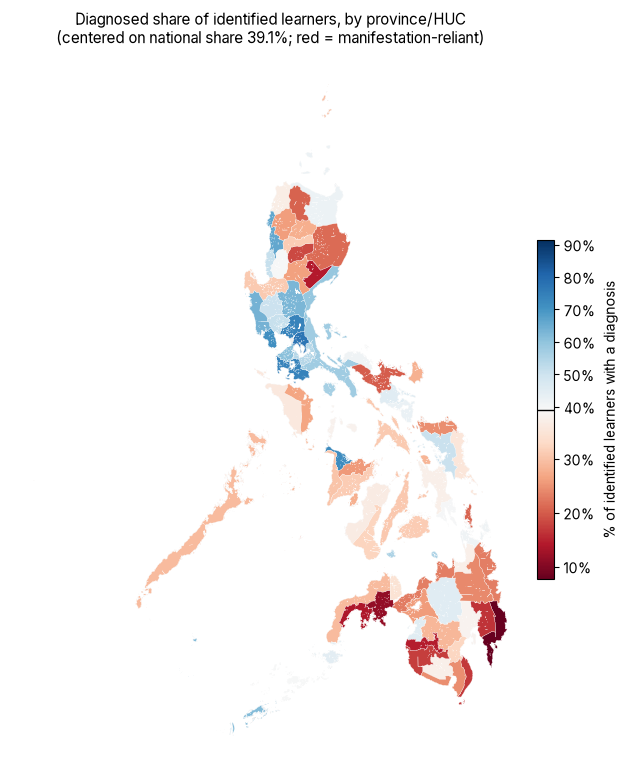

,psgc_province_name,region_short,identified,dx_share,gap_pp,z_adj
61,Davao Oriental,Davao Region,22800,0.077,-31.424,-5.122
48,Zamboanga del Sur,Zamboanga Peninsula,14818,0.113,-27.738,-3.645
49,Zamboanga Sibugay,Zamboanga Peninsula,8391,0.136,-25.437,-2.515
8,Quirino,Cagayan Valley,6071,0.142,-24.834,-2.089
115,Maguindanao del Sur,BARMM,4026,0.144,-24.676,-1.690
62,Davao de Oro,Davao Region,6469,0.164,-22.727,-1.973
63,Davao Occidental,Davao Region,2195,0.169,-22.180,-1.122
67,Sultan Kudarat,SOCCSKSARGEN,6131,0.175,-21.630,-1.828
89,Ifugao,CAR,1959,0.182,-20.859,-0.997
25,Camarines Sur,Bicol Region,24094,0.202,-18.928,-3.171


,psgc_province_name,region_short,identified,dx_share,gap_pp,z_adj
17,Batangas,CALABARZON,9182,0.741,35.019,3.622
21,Rizal,CALABARZON,8545,0.774,38.273,3.819
84,City of Taguig,NCR,2815,0.782,39.106,2.240
71,City of Las Piñas,NCR,1771,0.785,39.404,1.790
79,City of Parañaque,NCR,2680,0.827,43.604,2.437
82,Quezon City,NCR,9392,0.834,44.350,4.639
85,City of Valenzuela,NCR,2582,0.837,44.651,2.449
75,City of Manila,NCR,4484,0.867,47.648,3.444
78,City of Navotas,NCR,869,0.879,48.835,1.554
72,City of Makati,NCR,713,0.913,52.222,1.505


In [22]:
# ==========================================================================
# Choropleth: diagnosed share of identified learners, by
# province/HUC. Provinces below MIN_N_PROV are flat grey, not colored.
# ==========================================================================
prov_map = prov_gdf[['psgc_province', 'geometry']].merge(prov, on='psgc_province', how='left')
vmax = prov.loc[~prov['low_n'], 'dx_share'].max()
vmin = prov.loc[~prov['low_n'], 'dx_share'].min()
norm = TwoSlopeNorm(vcenter=P0, vmin=min(vmin, P0 - 1e-6), vmax=max(vmax, P0 + 1e-6))

def draw_prov(ax, gdf):
    low = gdf['low_n'].astype('boolean').fillna(True).astype(bool)
    if (~low).any():
        gdf[~low].plot(column='dx_share', cmap='RdBu', norm=norm, ax=ax, edgecolor='white', linewidth=0.2)
    if low.any():
        # Flat grey, NOT hatched, per instruction.
        gdf[low].plot(color="#101010", edgecolor='#9e9e9e', linewidth=0.2, ax=ax)
    ax.set_axis_off()

fig, ax = plt.subplots(figsize=(8, 11))
base_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='none')
draw_prov(ax, prov_map)
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=norm)
cb = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.01)
cb.set_label('% of identified learners with a diagnosis'); cb.ax.axhline(P0, color='black', lw=1)
cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title(f'Diagnosed share of identified learners, by province/HUC\n'
             f'(centered on national share {P0:.1%}; red = manifestation-reliant)', fontsize=11)
ncr = prov_map[prov_map['region_short'] == 'NCR']
if len(ncr):
    axin = ax.inset_axes([0.60, 0.62, 0.38, 0.30])
    draw_prov(axin, ncr); axin.set_title('NCR', fontsize=8)
# fig.savefig(FIG_DIR / "rq2_choropleth_province_dx_share.png", dpi=300, bbox_inches='tight')
plt.show()

display(prov[~prov['low_n']].sort_values('gap_pp')[['psgc_province_name', 'region_short', 'identified',
      'dx_share', 'gap_pp', 'z_adj']].head(10).round(3))
display(prov[~prov['low_n']].sort_values('gap_pp')[['psgc_province_name', 'region_short', 'identified',
      'dx_share', 'gap_pp', 'z_adj']].tail(10).round(3))

### **D. Exports**

In [25]:
# ==========================================================================
# Diagnosed share by grade level, by region (+ National).
# Full region set (not just the 4 highlighted in the regional per grade level chart).
# ==========================================================================
regional_grade_full = (grade_data.dropna(subset=['region_short'])
                        .groupby(['region_short', 'grade_level', 'diag_type'], as_index=False)['n'].sum())
national_grade_full = grade_data.groupby(['grade_level', 'diag_type'], as_index=False)['n'].sum()
national_grade_full.insert(0, 'region_short', 'National')

grade_region_export = pd.concat([national_grade_full, regional_grade_full], ignore_index=True)
grade_region_pivot = (grade_region_export
                      .pivot_table(index=['region_short', 'grade_level'], columns='diag_type',
                                   values='n', fill_value=0)
                      .rename(columns={DIAGNOSED: 'dx', MANIFEST: 'mf'})
                      .reset_index())
grade_region_pivot['identified'] = grade_region_pivot['dx'] + grade_region_pivot['mf']
grade_region_pivot['dx_share'] = (grade_region_pivot['dx'] / grade_region_pivot['identified']).round(4)

ROW_ORDER = ['National'] + REGION_ORDER
grade_region_pivot['region_short'] = pd.Categorical(grade_region_pivot['region_short'], categories=ROW_ORDER, ordered=True)
grade_region_pivot['grade_level'] = pd.Categorical(grade_region_pivot['grade_level'], categories=GRADE_ORDER, ordered=True)
grade_region_pivot = grade_region_pivot.sort_values(['region_short', 'grade_level']).reset_index(drop=True)

EXPORT_DIR = DATA / "exports"
grade_region_pivot.to_csv(EXPORT_DIR / "q2_diagnosed_share_by_grade_region.csv", index=False)
print(f"Saved {len(grade_region_pivot):,} rows -> {EXPORT_DIR / 'q2_diagnosed_share_by_grade_region.csv'}")
grade_region_pivot.head()


# ==========================================================================
# Diagnosed share of identified learners, by province/HUC, with the percentage-point gap from the national baseline.
# ==========================================================================
PROV_EXPORT_COLS = ['psgc_province', 'psgc_province_name', 'region_short',
                     'identified', 'dx', 'mf', 'dx_share', 'gap_pp', 'low_n']
prov_export = prov[PROV_EXPORT_COLS].sort_values(['region_short', 'psgc_province_name']).reset_index(drop=True)
prov_export['dx_share'] = prov_export['dx_share'].round(4)
prov_export['gap_pp'] = prov_export['gap_pp'].round(2)

prov_export.to_csv(EXPORT_DIR / "q2_diagnosed_share_by_province.csv", index=False)
print(f"Saved {len(prov_export):,} rows -> {EXPORT_DIR / 'q2_diagnosed_share_by_province.csv'}")
prov_export.head()


Saved 247 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q2_diagnosed_share_by_grade_region.csv
Saved 117 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q2_diagnosed_share_by_province.csv


,psgc_province,psgc_province_name,region_short,identified,dx,mf,dx_share,gap_pp,low_n
0,1900700000,Basilan,BARMM,397,177,220,0.4458,5.50,False
1,1903600000,Lanao del Sur,BARMM,1486,382,1104,0.2571,-13.38,False
2,1908700000,Maguindanao del Norte,BARMM,1582,710,872,0.4488,5.80,False
3,1908800000,Maguindanao del Sur,BARMM,4026,580,3446,0.1441,-24.68,False
4,1999900000,Special Geographic Area,BARMM,151,54,97,0.3576,-3.32,False
